<a href="https://colab.research.google.com/github/acastellanos-ie/NLP-MBDS-EN/blob/main/05_language_modeling/language_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Language Modeling: From One Token to a Sequence

So far we have used encoder models to analyse or represent text. Generative language models solve a different training problem: given the tokens seen so far, predict a probability distribution for the next token. A paragraph emerges by repeating that local prediction many times.

In this practice we will look below the convenient `generate()` method. We will inspect the logits for one prediction, build a small autoregressive loop ourselves and then change the decoding strategy. This lets us separate two ideas that are often mixed together: what the model has learned and how we choose tokens from its probability distribution.

In [1]:
# @title Setup
%pip install -q "requests==2.32.4" "transformers==5.16.1" "matplotlib==3.10.5"

import logging
import os
import warnings

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message=r"(?s).*HF_TOKEN.*")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("torchao").setLevel(logging.ERROR)
from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()

## Loading a causal decoder

We use DistilGPT-2, a smaller version of GPT-2 trained with a causal language-modelling objective. It runs quickly and exposes the same logits and generation interface that we need for the demonstration.

The objective is shared with larger decoder-only models, but the comparison should stop there. DistilGPT-2 is much smaller and older, has different training data and has not been instruction-tuned like a modern assistant. We use it to understand the mechanism, not to judge the quality of current LLMs.

In [2]:
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "distilbert/distilgpt2"
model_revision = "2290a62682d06624634c1f46a6ad5be0f47f38aa"
tokenizer = AutoTokenizer.from_pretrained(model_id, revision=model_revision)
model = AutoModelForCausalLM.from_pretrained(model_id, revision=model_revision)
model.eval()

print(f"Model: {model_id}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: distilbert/distilgpt2
Vocabulary size: 50,257
Parameters: 81,912,576


## The next-token distribution

Feed the model an unfinished sentence. The final position produces one logit for every token in the vocabulary. Softmax turns those logits into probabilities.

Prompt: 'The capital of France is'

' the'        11.77%
' home'        8.23%
' now'         4.99%
' a'           4.93%
' being'       3.56%
' one'         2.11%
' known'       1.89%
' also'        1.88%
' in'          1.80%
' to'          1.40%


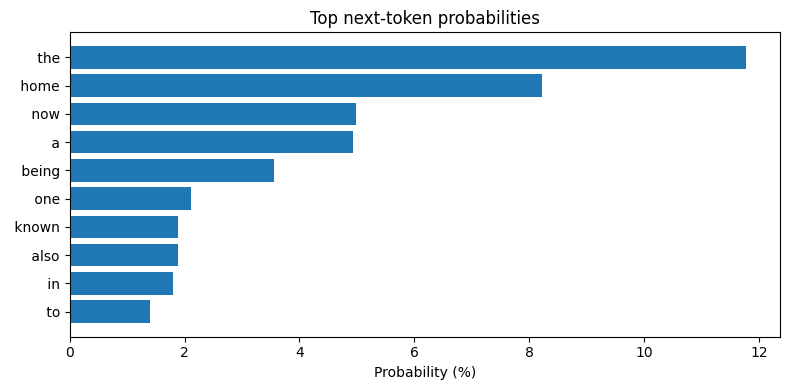

In [3]:
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

next_token_logits = outputs.logits[0, -1]
next_token_probabilities = torch.softmax(next_token_logits, dim=-1)
top_probabilities, top_indices = torch.topk(next_token_probabilities, k=10)
top_tokens = [tokenizer.decode([index]) for index in top_indices]

print(f"Prompt: {prompt!r}\n")
for token, probability in zip(top_tokens, top_probabilities):
    print(f"{token!r:<12} {probability.item() * 100:6.2f}%")

plt.figure(figsize=(8, 4))
plt.barh(top_tokens[::-1], top_probabilities.numpy()[::-1] * 100)
plt.xlabel("Probability (%)")
plt.title("Top next-token probabilities")
plt.tight_layout()
plt.show()

The most likely next token is `' the'`, not `' Paris'`, and its probability is only about 11.8%. The model is choosing among many plausible continuations.

## Greedy generation from scratch

Greedy decoding takes the highest-logit token, appends it to the input and repeats. The code below implements that loop and compares it with `model.generate`.

In [4]:
def greedy_generate(prompt, max_new_tokens=15):
    current_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    selected_tokens = []

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(current_ids).logits[0, -1]
        next_token_id = torch.argmax(logits).reshape(1, 1)
        selected_tokens.append(tokenizer.decode(next_token_id[0]))
        current_ids = torch.cat([current_ids, next_token_id], dim=1)

    return tokenizer.decode(current_ids[0]), selected_tokens

manual_text, selected_tokens = greedy_generate(prompt)
built_in_ids = model.generate(
    **inputs,
    max_new_tokens=15,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
)
built_in_text = tokenizer.decode(built_in_ids[0])

print("Selected tokens:")
print(selected_tokens)
print("\nManual loop:")
print(manual_text)
print("\nBuilt-in generate gives the same result:")
print(manual_text == built_in_text)

Selected tokens:
[' the', ' capital', ' of', ' the', ' French', ' Republic', '.', ' The', ' capital', ' of', ' France', ' is', ' the', ' capital', ' of']

Manual loop:
The capital of France is the capital of the French Republic. The capital of France is the capital of

Built-in generate gives the same result:
True


The manual loop and `generate` agree. The output is grammatical but becomes repetitive: *the capital of France is the capital of...* Greedy decoding is deterministic, but the locally best token does not guarantee a good sequence.

## Penalising repetition

A common way to discourage loops is to penalise tokens that have already appeared before selecting the next one. This changes the decoding trajectory, but it does not retrain the model or add any new knowledge.

In [5]:
penalised_ids = model.generate(
    **inputs,
    max_new_tokens=15,
    do_sample=False,
    repetition_penalty=1.2,
    pad_token_id=tokenizer.eos_token_id,
)
penalised_text = tokenizer.decode(penalised_ids[0])

print("Without penalty:")
print(built_in_text)
print("\nWith repetition_penalty=1.2:")
print(penalised_text)

Without penalty:
The capital of France is the capital of the French Republic. The capital of France is the capital of

With repetition_penalty=1.2:
The capital of France is the largest city in Europe, with a population more than twice as large.


Without the penalty, the model repeats *the capital of* until the token budget ends. With a penalty of 1.2, it produces *the largest city in Europe...* The second continuation is less repetitive, but the rule does not verify the claim: better decoding is not fact checking.

## What temperature changes

Temperature divides the logits before softmax. A low value sharpens the distribution; a high value flattens it. We can measure that change with entropy instead of calling it ‘creativity’.

In [6]:
temperatures = [0.5, 1.0, 1.5]
temperature_stats = []

for temperature in temperatures:
    probabilities = torch.softmax(next_token_logits / temperature, dim=-1)
    entropy = -(probabilities * torch.log2(probabilities.clamp_min(1e-12))).sum()
    top_probability = probabilities.max()
    temperature_stats.append((temperature, entropy.item(), top_probability.item()))
    print(
        f"temperature={temperature:.1f} | entropy={entropy.item():.2f} bits | "
        f"top-token probability={top_probability.item() * 100:.2f}%"
    )

temperature=0.5 | entropy=2.68 bits | top-token probability=45.90%
temperature=1.0 | entropy=7.80 bits | top-token probability=11.77%
temperature=1.5 | entropy=11.78 bits | top-token probability=2.35%


At temperature 0.5, almost half of the probability mass goes to the top token. At 1.5, the top token receives only about 2.3% and entropy is much higher. Temperature changes uncertainty; it does not add facts or reasoning to the model.

## Sampling the distribution

Generate three continuations at two temperatures. The seeds are fixed so the examples are reproducible.

In [7]:
sampling_prompt = "The scientist opened the door and saw"
sampling_inputs = tokenizer(sampling_prompt, return_tensors="pt")
sampled_texts = {}

for temperature in [0.5, 1.5]:
    print(f"\n--- Temperature {temperature} ---")
    sampled_texts[temperature] = []
    for seed in [7, 21, 42]:
        torch.manual_seed(seed)
        output_ids = model.generate(
            **sampling_inputs,
            max_new_tokens=18,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id,
        )
        text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        sampled_texts[temperature].append(text)
        print(f"seed={seed}: {text}")


--- Temperature 0.5 ---
seed=7: The scientist opened the door and saw a woman in the middle of the street. She looked like a woman with a long dark
seed=21: The scientist opened the door and saw a man standing in the doorway.



"I can't believe he was
seed=42: The scientist opened the door and saw a woman holding a knife.













--- Temperature 1.5 ---
seed=7: The scientist opened the door and saw only a few other researchers, most of them with their hands. They looked to her with
seed=21: The scientist opened the door and saw a tiny girl in blue with the head of her mother's hair. When she opened her
seed=42: The scientist opened the door and saw himself there," a female voice in shock."Yes . ."When?" replied Harry again."


Both settings vary because both sample from a distribution. The higher temperature explores less likely tokens and the outputs become less predictable, but sometimes also less coherent. One sample is not enough to compare decoding strategies; that is why we used several fixed seeds.

# Takeaway

- A causal language model predicts the next token, not a complete paragraph.
- Generation is a loop that feeds each selected token back into the model.
- Greedy decoding can be fluent and still repetitive or unhelpful.
- A repetition penalty can change the trajectory without adding or checking knowledge.
- Temperature reshapes a probability distribution. Higher is not automatically better or more creative.
- Fluent text is not evidence that a factual answer is correct.

## Things to try

- Change the prompt and inspect whether the highest-probability token is as predictable as it first appears.
- Increase the generation length and observe when greedy decoding begins to repeat.
- Keep the temperature fixed and add top-k or top-p sampling to see which source of variation each setting controls.